In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk

In [2]:
# Define the local folder filename
csv_filename = 'ita_wine_reviews.csv'
# Read the CSV file from the specified path
full_path = os.path.join(r'C:\Users\TobyWong\Desktop\UNCC\6211\Assignment_3\text_mining\data', csv_filename)
df = pd.read_csv(full_path)
df.head()

,title,description,designation,points,price,province,variety,winery
0,Nicosia 2013 Vulkà Bianco (Etna),"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,White Blend,Nicosia
1,Terre di Giurfo 2013 Belsito Frappato (Vittoria),"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Frappato,Terre di Giurfo
2,Masseria Setteporte 2012 Rosso (Etna),This is dominated by oak and oak-driven aromas...,Rosso,87,NaN,Sicily & Sardinia,Nerello Mascalese,Masseria Setteporte
3,Baglio di Pianetto 2007 Ficiligno White (Sicilia),Delicate aromas recall white flower and citrus...,Ficiligno,87,19.0,Sicily & Sardinia,White Blend,Baglio di Pianetto
4,Canicattì 2009 Aynat Nero d'Avola (Sicilia),"Aromas of prune, blackcurrant, toast and oak c...",Aynat,87,35.0,Sicily & Sardinia,Nero d'Avola,Canicattì


In [3]:
text_series_desc = df['description'].copy()          # For Recall Description
text_series = text_series_desc

def dim(text_series = text_series):
    dimensions = len(set(text_series.str.split().explode().values))
    # same result:
    # dimensions = len(text_series.str.split().explode().unique())
    print(f'{dimensions} dimensions in the potential DFM.')


# Create a function to display top N words and frequency
def top_words(text_series = text_series, n=20):
    freq = text_series.str.split().explode().value_counts()[:n]
    print(f'Top {n} words:\n{freq}')

dim()
top_words()

17941 dimensions in the potential DFM.
Top 20 words:
description
and        48285
of         28217
the        18648
a          18519
with       14614
The        11105
aromas      8951
palate      8436
is          8075
this        7692
wine        6113
offers      5645
This        5637
black       5539
to          5070
that        4795
in          4696
cherry,     4449
on          4133
white       4124
Name: count, dtype: int64


Text Preprocessing

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

comments = df["description"].fillna("").astype(str).str.lower()

# Remove stopwords
stop = stopwords.words('english')
comments = comments.apply(lambda x: " ".join(word for word in x.split() if word not in stop))

# Remove punctuation
comments = comments.str.replace(pat=r'[^\w\s]', repl=' ', regex=True)

# Remove digits
comments = comments.str.replace(pat=r'\d+', repl=' ', regex=True)

# Remove extra spaces
comments = comments.str.replace(pat=r'\s+', repl=' ', regex=True).str.strip()

# Lemmatization
lemmatizer = WordNetLemmatizer()
comments = comments.apply(
    lambda x: " ".join(lemmatizer.lemmatize(word) for word in x.split())
)

# Save cleaned text
df["description_clean"] = comments

# Tokenization without NLTK punkt
df["description_tokens"] = df["description_clean"].apply(lambda x: x.split())

print(df[["description", "description_clean", "description_tokens"]].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                         description  \
0  Aromas include tropical fruit, broom, brimston...   
1  Here's a bright, informal red that opens with ...   
2  This is dominated by oak and oak-driven aromas...   
3  Delicate aromas recall white flower and citrus...   
4  Aromas of prune, blackcurrant, toast and oak c...   

                                   description_clean  \
0  aroma include tropical fruit broom brimstone d...   
1  here s bright informal red open aroma candied ...   
2  dominated oak oak driven aroma include roasted...   
3  delicate aroma recall white flower citrus pala...   
4  aroma prune blackcurrant toast oak carry extra...   

                                  description_tokens  
0  [aroma, include, tropical, fruit, broom, brims...  
1  [here, s, bright, informal, red, open, aroma, ...  
2  [dominated, oak, oak, driven, aroma, include, ...  
3  [delicate, aroma, recall, white, flower, citru...  
4  [aroma, prune, blackcurrant, toast, oak, carry..

Word Cloud

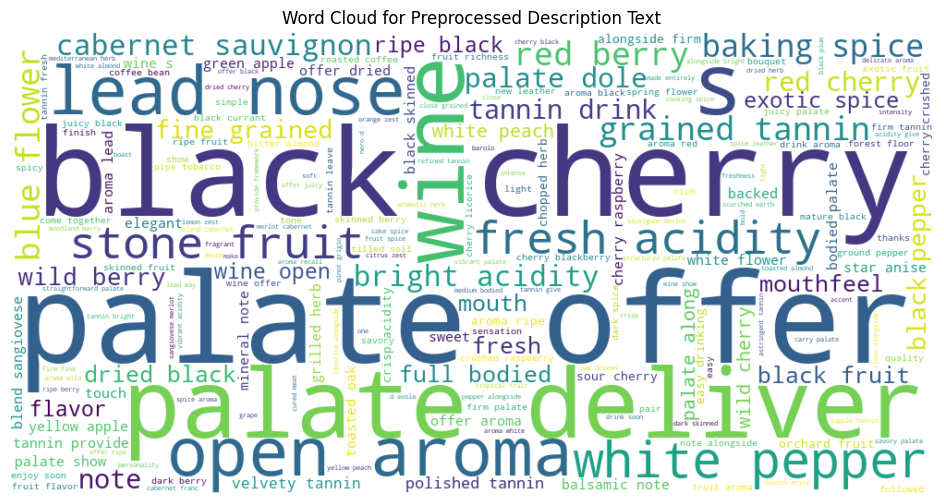

In [ ]:
# Combine all cleaned text into one string
text_for_wordcloud = " ".join(df["description_clean"].dropna().astype(str))

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(text_for_wordcloud)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Preprocessed Description Text")
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


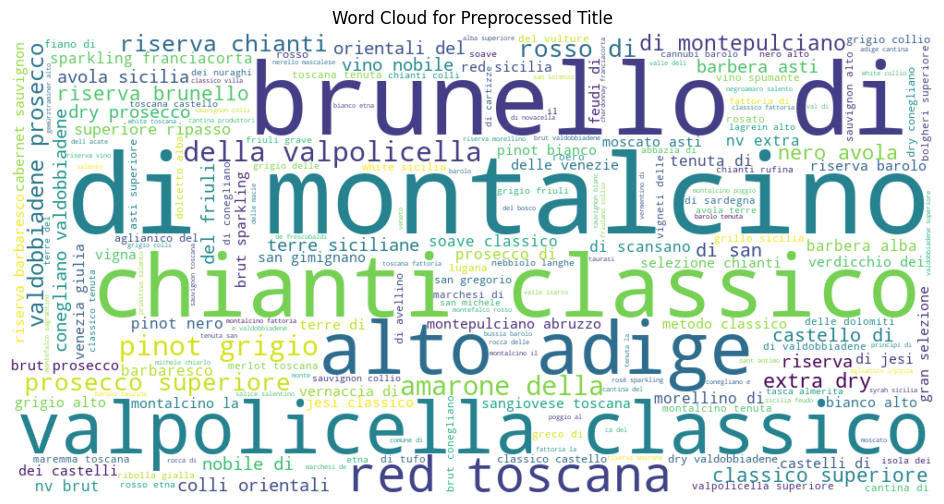

In [ ]:
stop = set(stopwords.words("english"))

title_series = df["title"].fillna("").astype(str).str.lower()
title_series = title_series.str.replace(r"[^\w\s]", " ", regex=True)
title_series = title_series.str.replace(r"\d+", " ", regex=True)
title_series = title_series.str.replace(r"\s+", " ", regex=True).str.strip()
title_series = title_series.apply(lambda x: " ".join(word for word in x.split() if word not in stop))

title_text = " ".join(title_series)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(title_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Preprocessed Title")
plt.show()

In [7]:
import numpy as np
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity

tokenized_docs = df["description_clean"].fillna("").apply(lambda x: x.split()).tolist()
tokenized_docs = [doc for doc in tokenized_docs if len(doc) > 0]

all_tokens = [token for doc in tokenized_docs for token in doc]
term_counts = Counter(all_tokens)

# remove very rare words to reduce noise
min_freq = 2
vocab = sorted([term for term, count in term_counts.items() if count >= min_freq])
vocab_index = {term: i for i, term in enumerate(vocab)}

print(f"Vocabulary size (min_freq={min_freq}):", len(vocab))

# build co-occurrence matrix
window_size = 2  # words within +/- 2 positions count as context
cooc_matrix = np.zeros((len(vocab), len(vocab)), dtype=np.float64)

for doc in tokenized_docs:
    for i, term in enumerate(doc):
        if term not in vocab_index:
            continue
        term_i = vocab_index[term]

        start = max(0, i - window_size)
        end = min(len(doc), i + window_size + 1)

        for j in range(start, end):
            if i == j:
                continue
            context_term = doc[j]
            if context_term not in vocab_index:
                continue
            term_j = vocab_index[context_term]
            cooc_matrix[term_i, term_j] += 1

# Similarity function
def top_similar_terms(seed_word, cooc_matrix, vocab, vocab_index, top_n=5):
    if seed_word not in vocab_index:
        return f'"{seed_word}" not found in vocabulary after preprocessing.'

    seed_idx = vocab_index[seed_word]
    seed_vector = cooc_matrix[seed_idx].reshape(1, -1)

    similarities = cosine_similarity(seed_vector, cooc_matrix)[0]

    # Exclude the seed word itself
    similar_terms = []
    for idx, score in enumerate(similarities):
        term = vocab[idx]
        if term != seed_word:
            similar_terms.append((term, score))

    similar_terms = sorted(similar_terms, key=lambda x: x[1], reverse=True)[:top_n]
    return similar_terms

seed_words = ["fruit", "oak", "finish"]

results = {}
for seed in seed_words:
    results[seed] = top_similar_terms(seed, cooc_matrix, vocab, vocab_index, top_n=5)

for seed, sims in results.items():
    print(f"\nTop 5 terms most similar to '{seed}' using Cosine Similarity:")
    if isinstance(sims, str):
        print(sims)
    else:
        for term, score in sims:
            print(f"  {term:<20} similarity = {score:.4f}")

rows = []
for seed, sims in results.items():
    if isinstance(sims, list):
        for rank, (term, score) in enumerate(sims, start=1):
            rows.append([seed, rank, term, score])

results_df = pd.DataFrame(rows, columns=["seed_word", "rank", "similar_term", "cosine_similarity"])
print("\nDetailed results table:")
print(results_df)

Vocabulary size (min_freq=2): 5303

Top 5 terms most similar to 'fruit' using Cosine Similarity:
  plum                 similarity = 0.7074
  mature               similarity = 0.6432
  berry                similarity = 0.6308
  subtle               similarity = 0.6253
  ripe                 similarity = 0.6127

Top 5 terms most similar to 'oak' using Cosine Similarity:
  nut                  similarity = 0.7026
  toast                similarity = 0.6978
  hazelnut             similarity = 0.6879
  espresso             similarity = 0.6465
  vanilla              similarity = 0.6422

Top 5 terms most similar to 'finish' using Cosine Similarity:
  close                similarity = 0.6388
  end                  similarity = 0.6179
  mouth                similarity = 0.5388
  mineral              similarity = 0.5284
  wood                 similarity = 0.5283

Detailed results table:
   seed_word  rank similar_term  cosine_similarity
0      fruit     1         plum           0.707375
1      f

Topic Modeling

In [8]:
import pandas as pd
import nltk
import warnings
warnings.filterwarnings("ignore")

from gensim import corpora
from gensim.models import LdaModel
from pprint import pprint

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

texts = df["description_clean"].fillna("").apply(lambda x: x.split()).tolist()

# Remove empty documents
texts = [doc for doc in texts if len(doc) > 0]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.5)  
# no_below=2  -> keep words appearing in at least 2 docs
# no_above=0.5 -> remove words appearing in more than 50% of docs

corpus = [dictionary.doc2bow(text) for text in texts]

num_topics = 3

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

print("Top 10 words per topic:\n")
for topic_id, topic_words in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {topic_id + 1}:")
    print(topic_words)
    print()

vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

Top 10 words per topic:

Topic 1:
0.035*"tannin" + 0.030*"cherry" + 0.028*"black" + 0.018*"drink" + 0.018*"berry" + 0.015*"alongside" + 0.015*"spice" + 0.015*"offer" + 0.015*"red" + 0.014*"note"

Topic 2:
0.039*"wine" + 0.023*"fruit" + 0.018*"s" + 0.014*"spice" + 0.011*"cherry" + 0.010*"show" + 0.010*"bright" + 0.008*"mouth" + 0.008*"note" + 0.008*"tone"

Topic 3:
0.032*"white" + 0.024*"fruit" + 0.023*"acidity" + 0.022*"peach" + 0.020*"apple" + 0.019*"citrus" + 0.018*"note" + 0.017*"offer" + 0.015*"flower" + 0.015*"fresh"



In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

# Drop text columns and other derived columns that should not be used
drop_cols = [
    "description",
    "description_clean",
    "description_tokens",
    "bow",
    "Top_Rated",
    "points"
]
drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

# Extra safety: remove any remaining columns that contain lists/dicts/sets
bad_cols = []
for col in X.columns:
    sample_vals = X[col].dropna()
    if len(sample_vals) > 0:
        if sample_vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
            bad_cols.append(col)

if bad_cols:
    print("Dropping non-scalar columns:", bad_cols)
    X = X.drop(columns=bad_cols)

# Now detect categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("\nUnique value counts for categorical columns:\n")

for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()

for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

print("\nValue counts after bucketing rare categories:\n")
for col in categorical_cols:
    print(f"\n{col}:")
    print(X_buck[col].value_counts().head(15))

X_train, X_test, y_train, y_test = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model1_logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model1_logit.fit(X_train, y_train)

y_pred_logit = model1_logit.predict(X_test)
y_prob_logit = model1_logit.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Performance:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_logit), 4))
print("Precision:", round(precision_score(y_test, y_pred_logit), 4))
print("Recall:", round(recall_score(y_test, y_pred_logit), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_logit), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_logit), 4))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\1449520730.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


Categorical columns: ['title', 'designation', 'province', 'variety', 'winery']
Numeric columns: ['price']

Unique value counts for categorical columns:

title: 17805 unique values
designation: 6709 unique values
province: 10 unique values
variety: 189 unique values
winery: 2934 unique values

Value counts after bucketing rare categories:


title:
title
Other    17940
Name: count, dtype: int64

designation:
designation
Other      12159
Missing     5142
Riserva      639
Name: count, dtype: int64

province:
province
Tuscany               5391
Piedmont              3441
Veneto                2501
Northeastern Italy    1967
Sicily & Sardinia     1634
Southern Italy        1254
Central Italy         1134
Lombardy               481
Other                  137
Name: count, dtype: int64

variety:
variety
Other                            4358
Red Blend                        3332
Nebbiolo                         2544
Sangiovese                       2053
White Blend                       725
Sang

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

text_col = "description_clean" if "description_clean" in df_model.columns else "description"

df_model[text_col] = df_model[text_col].fillna("").astype(str)

drop_cols = [
    "Top_Rated",
    "points",
    "description_tokens",
    "bow"
]

if "description" in df_model.columns and text_col != "description":
    drop_cols.append("description")
if "description_clean" in df_model.columns and text_col != "description_clean":
    drop_cols.append("description_clean")

drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

non_text_cols = [col for col in X.columns if col != text_col]
X_non_text = X[non_text_cols].copy()

bad_cols = []
for col in X_non_text.columns:
    vals = X_non_text[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    print("Dropping non-scalar columns from non-text features:", bad_cols)
    X_non_text = X_non_text.drop(columns=bad_cols)
    non_text_cols = X_non_text.columns.tolist()

# Reassemble X with non-text + text column
X = X_non_text.copy()
X[text_col] = df_model[text_col]

categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_non_text.select_dtypes(include=[np.number]).columns.tolist()

print("Text column used for LSI:", text_col)
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()

for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_buck[text_col] = X_buck[text_col].fillna("").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# LSI = TF-IDF + TruncatedSVD
text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("svd", TruncatedSVD(n_components=5, random_state=42))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("text_lsi", text_transformer, text_col)
    ]
)

model2_logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

model2_logit.fit(X_train, y_train)

y_pred = model2_logit.predict(X_test)
y_prob = model2_logit.predict_proba(X_test)[:, 1]

print("\nModel 2 Performance (Non-text + LSI text features):")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Text column used for LSI: description_clean
Categorical columns: ['title', 'designation', 'province', 'variety', 'winery']
Numeric columns: ['price']


C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\98946549.py:61: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()



Model 2 Performance (Non-text + LSI text features):
Accuracy: 0.7821
Precision: 0.6725
Recall: 0.7181
F1 Score: 0.6945
ROC AUC: 0.8506

Confusion Matrix:
[[1917  433]
 [ 349  889]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      2350
           1       0.67      0.72      0.69      1238

    accuracy                           0.78      3588
   macro avg       0.76      0.77      0.76      3588
weighted avg       0.79      0.78      0.78      3588



Model 1 with random forest

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

drop_cols = [
    "description",
    "description_clean",
    "description_tokens",
    "bow",
    "Top_Rated",
    "points"
]
drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

bad_cols = []
for col in X.columns:
    vals = X[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X = X.drop(columns=bad_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_train, X_test, y_train, y_test = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model1_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model1_rf.fit(X_train, y_train)

y_pred_rf = model1_rf.predict(X_test)
y_prob_rf = model1_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance: Model 1 (Non-text only)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\3141975336.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()



Random Forest Performance: Model 1 (Non-text only)
Accuracy: 0.7285
Precision: 0.5918
Recall: 0.6874
F1 Score: 0.636
ROC AUC: 0.7936

Confusion Matrix:
[[1763  587]
 [ 387  851]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78      2350
           1       0.59      0.69      0.64      1238

    accuracy                           0.73      3588
   macro avg       0.71      0.72      0.71      3588
weighted avg       0.74      0.73      0.73      3588



In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

text_col = "description_clean" if "description_clean" in df_model.columns else "description"
df_model[text_col] = df_model[text_col].fillna("").astype(str)

drop_cols = [
    "Top_Rated",
    "points",
    "description_tokens",
    "bow"
]

if "description" in df_model.columns and text_col != "description":
    drop_cols.append("description")
if "description_clean" in df_model.columns and text_col != "description_clean":
    drop_cols.append("description_clean")

drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

non_text_cols = [col for col in X.columns if col != text_col]
X_non_text = X[non_text_cols].copy()

bad_cols = []
for col in X_non_text.columns:
    vals = X_non_text[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X_non_text = X_non_text.drop(columns=bad_cols)

X = X_non_text.copy()
X[text_col] = df_model[text_col]

categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_non_text.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_buck[text_col] = X_buck[text_col].fillna("").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("svd", TruncatedSVD(n_components=5, random_state=42))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("text_lsi", text_transformer, text_col)
    ]
)

model2_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

model2_rf.fit(X_train, y_train)

y_pred_rf = model2_rf.predict(X_test)
y_prob_rf = model2_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance: Model 2 (Non-text + LSI text)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\213602871.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()



Random Forest Performance: Model 2 (Non-text + LSI text)
Accuracy: 0.8311
Precision: 0.7931
Recall: 0.6906
F1 Score: 0.7383
ROC AUC: 0.8929

Confusion Matrix:
[[2127  223]
 [ 383  855]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      2350
           1       0.79      0.69      0.74      1238

    accuracy                           0.83      3588
   macro avg       0.82      0.80      0.81      3588
weighted avg       0.83      0.83      0.83      3588



Model comparison

Validation AUC-ROC
Model 1 (Non-text only): 0.7936
Model 2 (Non-text + LSI text): 0.8929
Model 2 performs better based on AUC-ROC.


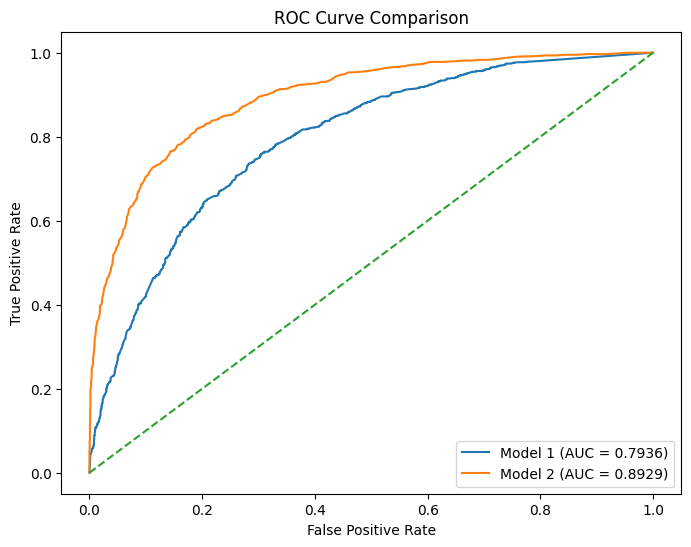

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_model1 = model1_rf.predict_proba(X_test)[:, 1]
y_prob_model2 = model2_rf.predict_proba(X_test)[:, 1]

auc_model1 = roc_auc_score(y_test, y_prob_model1)
auc_model2 = roc_auc_score(y_test, y_prob_model2)

print("Validation AUC-ROC")
print("Model 1 (Non-text only):", round(auc_model1, 4))
print("Model 2 (Non-text + LSI text):", round(auc_model2, 4))

if auc_model2 > auc_model1:
    print("Model 2 performs better based on AUC-ROC.")
elif auc_model1 > auc_model2:
    print("Model 1 performs better based on AUC-ROC.")
else:
    print("Both models have the same AUC-ROC.")

fpr1, tpr1, _ = roc_curve(y_test, y_prob_model1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_model2)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Model 1 (AUC = {auc_model1:.4f})")
plt.plot(fpr2, tpr2, label=f"Model 2 (AUC = {auc_model2:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

SVM on model 1 using default model settings, no hyperparameter tuning

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

drop_cols = [
    "description",
    "description_clean",
    "description_tokens",
    "bow",
    "Top_Rated",
    "points"
]
drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

bad_cols = []
for col in X.columns:
    vals = X[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X = X.drop(columns=bad_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model1_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

model1_svm.fit(X_train_1, y_train_1)

y_pred_svm_1 = model1_svm.predict(X_test_1)
y_prob_svm_1 = model1_svm.predict_proba(X_test_1)[:, 1]

print("\nSVM Performance: Model 1 (Non-text only)")
print("Accuracy:", round(accuracy_score(y_test_1, y_pred_svm_1), 4))
print("Precision:", round(precision_score(y_test_1, y_pred_svm_1), 4))
print("Recall:", round(recall_score(y_test_1, y_pred_svm_1), 4))
print("F1 Score:", round(f1_score(y_test_1, y_pred_svm_1), 4))
print("ROC AUC:", round(roc_auc_score(y_test_1, y_prob_svm_1), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1, y_pred_svm_1))

print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_svm_1))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\4125122241.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()



SVM Performance: Model 1 (Non-text only)
Accuracy: 0.7467
Precision: 0.6193
Recall: 0.6898
F1 Score: 0.6527
ROC AUC: 0.8128

Confusion Matrix:
[[1825  525]
 [ 384  854]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2350
           1       0.62      0.69      0.65      1238

    accuracy                           0.75      3588
   macro avg       0.72      0.73      0.73      3588
weighted avg       0.75      0.75      0.75      3588



SVM for model 2 with default model settings, no hyperparameter tuning

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

text_col = "description_clean" if "description_clean" in df_model.columns else "description"
df_model[text_col] = df_model[text_col].fillna("").astype(str)

drop_cols = [
    "Top_Rated",
    "points",
    "description_tokens",
    "bow"
]

if "description" in df_model.columns and text_col != "description":
    drop_cols.append("description")
if "description_clean" in df_model.columns and text_col != "description_clean":
    drop_cols.append("description_clean")

drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

non_text_cols = [col for col in X.columns if col != text_col]
X_non_text = X[non_text_cols].copy()

bad_cols = []
for col in X_non_text.columns:
    vals = X_non_text[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X_non_text = X_non_text.drop(columns=bad_cols)

X = X_non_text.copy()
X[text_col] = df_model[text_col]

categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_non_text.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_buck[text_col] = X_buck[text_col].fillna("").astype(str)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("svd", TruncatedSVD(n_components=5, random_state=42))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("text_lsi", text_transformer, text_col)
    ]
)

model2_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

model2_svm.fit(X_train_2, y_train_2)

y_pred_svm_2 = model2_svm.predict(X_test_2)
y_prob_svm_2 = model2_svm.predict_proba(X_test_2)[:, 1]

print("\nSVM Performance: Model 2 (Non-text + LSI text)")
print("Accuracy:", round(accuracy_score(y_test_2, y_pred_svm_2), 4))
print("Precision:", round(precision_score(y_test_2, y_pred_svm_2), 4))
print("Recall:", round(recall_score(y_test_2, y_pred_svm_2), 4))
print("F1 Score:", round(f1_score(y_test_2, y_pred_svm_2), 4))
print("ROC AUC:", round(roc_auc_score(y_test_2, y_prob_svm_2), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2, y_pred_svm_2))

print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_svm_2))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\215372967.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()



SVM Performance: Model 2 (Non-text + LSI text)
Accuracy: 0.7469
Precision: 0.6194
Recall: 0.6914
F1 Score: 0.6534
ROC AUC: 0.8178

Confusion Matrix:
[[1824  526]
 [ 382  856]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2350
           1       0.62      0.69      0.65      1238

    accuracy                           0.75      3588
   macro avg       0.72      0.73      0.73      3588
weighted avg       0.76      0.75      0.75      3588



Validation AUC-ROC
Model 1 (Non-text only, SVM): 0.8128
Model 2 (Non-text + LSI text, SVM): 0.8178
Model 2 performs better based on AUC-ROC.


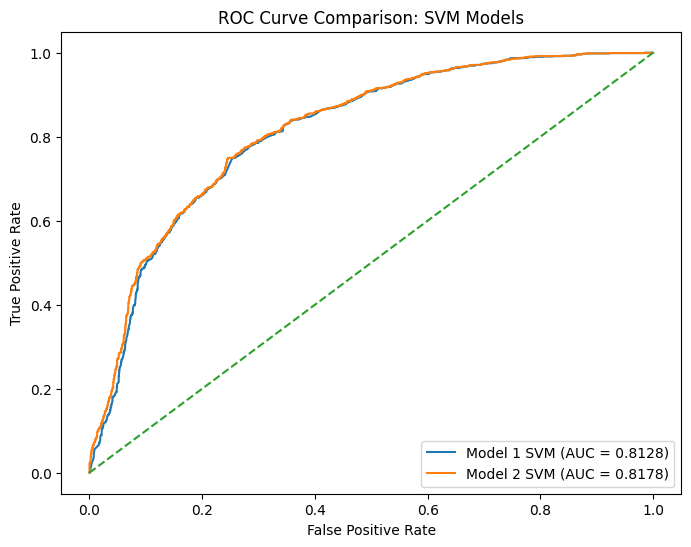

In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob_model1 = model1_svm.predict_proba(X_test_1)[:, 1]
y_prob_model2 = model2_svm.predict_proba(X_test_2)[:, 1]

auc_model1 = roc_auc_score(y_test_1, y_prob_model1)
auc_model2 = roc_auc_score(y_test_2, y_prob_model2)

print("Validation AUC-ROC")
print("Model 1 (Non-text only, SVM):", round(auc_model1, 4))
print("Model 2 (Non-text + LSI text, SVM):", round(auc_model2, 4))

if auc_model2 > auc_model1:
    print("Model 2 performs better based on AUC-ROC.")
elif auc_model1 > auc_model2:
    print("Model 1 performs better based on AUC-ROC.")
else:
    print("Both models have the same AUC-ROC.")

fpr1, tpr1, _ = roc_curve(y_test_1, y_prob_model1)
fpr2, tpr2, _ = roc_curve(y_test_2, y_prob_model2)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Model 1 SVM (AUC = {auc_model1:.4f})")
plt.plot(fpr2, tpr2, label=f"Model 2 SVM (AUC = {auc_model2:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: SVM Models")
plt.legend(loc="lower right")
plt.show()

XGBoost with hyperparameter tuning CUDA ENABLED

In [18]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

drop_cols = [
    "description",
    "description_clean",
    "description_tokens",
    "bow",
    "Top_Rated",
    "points"
]
drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

bad_cols = []
for col in X.columns:
    vals = X[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X = X.drop(columns=bad_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

X_tune_1, _, y_tune_1, _ = train_test_split(
    X_train_1, y_train_1, train_size=0.15, random_state=42, stratify=y_train_1
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

xgb_pipe_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        random_state=42
    ))
])

param_dist_1 = {
    "classifier__n_estimators": randint(100, 400),
    "classifier__max_depth": randint(3, 8),
    "classifier__learning_rate": uniform(0.03, 0.17),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 8),
    "classifier__gamma": uniform(0.0, 0.5)
}

random_search_1 = RandomizedSearchCV(
    estimator=xgb_pipe_1,
    param_distributions=param_dist_1,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search_1.fit(X_tune_1, y_tune_1)

model1_xgb_rs = random_search_1.best_estimator_
model1_xgb_rs.fit(X_train_1, y_train_1)

y_pred_xgb_1 = model1_xgb_rs.predict(X_test_1)
y_prob_xgb_1 = model1_xgb_rs.predict_proba(X_test_1)[:, 1]

print("Best parameters for Model 1:")
print(random_search_1.best_params_)

print("\nXGBoost Performance: Model 1 (Non-text only, CUDA, RandomizedSearchCV)")
print("Accuracy:", round(accuracy_score(y_test_1, y_pred_xgb_1), 4))
print("Precision:", round(precision_score(y_test_1, y_pred_xgb_1), 4))
print("Recall:", round(recall_score(y_test_1, y_pred_xgb_1), 4))
print("F1 Score:", round(f1_score(y_test_1, y_pred_xgb_1), 4))
print("ROC AUC:", round(roc_auc_score(y_test_1, y_prob_xgb_1), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1, y_pred_xgb_1))

print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_xgb_1))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\30528636.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Model 1:
{'classifier__colsample_bytree': np.float64(0.9861021229056552), 'classifier__gamma': np.float64(0.30351712384334234), 'classifier__learning_rate': np.float64(0.07691986094383238), 'classifier__max_depth': 7, 'classifier__min_child_weight': 7, 'classifier__n_estimators': 164, 'classifier__subsample': np.float64(0.6062545626964776)}

XGBoost Performance: Model 1 (Non-text only, CUDA, RandomizedSearchCV)
Accuracy: 0.7723
Precision: 0.6902
Recall: 0.6171
F1 Score: 0.6516
ROC AUC: 0.8279

Confusion Matrix:
[[2007  343]
 [ 474  764]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      2350
           1       0.69      0.62      0.65      1238

    accuracy                           0.77      3588
   macro avg       0.75      0.74      0.74      3588
weighted avg       0.77      0.77      0.77      3588



In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

df_model = df.copy()
df_model["Top_Rated"] = (df_model["points"] >= 90).astype(int)

text_col = "description_clean" if "description_clean" in df_model.columns else "description"
df_model[text_col] = df_model[text_col].fillna("").astype(str)

drop_cols = [
    "Top_Rated",
    "points",
    "description_tokens",
    "bow"
]

if "description" in df_model.columns and text_col != "description":
    drop_cols.append("description")
if "description_clean" in df_model.columns and text_col != "description_clean":
    drop_cols.append("description_clean")

drop_cols = [col for col in drop_cols if col in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model["Top_Rated"]

non_text_cols = [col for col in X.columns if col != text_col]
X_non_text = X[non_text_cols].copy()

bad_cols = []
for col in X_non_text.columns:
    vals = X_non_text[col].dropna()
    if len(vals) > 0 and vals.apply(lambda v: isinstance(v, (list, dict, set))).any():
        bad_cols.append(col)

if bad_cols:
    X_non_text = X_non_text.drop(columns=bad_cols)

X = X_non_text.copy()
X[text_col] = df_model[text_col]

categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_non_text.select_dtypes(include=[np.number]).columns.tolist()

def bucket_rare_categories(series, min_freq=0.01):
    freq = series.value_counts(normalize=True)
    keep = freq[freq >= min_freq].index
    return series.where(series.isin(keep), other="Other")

X_buck = X.copy()
for col in categorical_cols:
    X_buck[col] = X_buck[col].fillna("Missing").astype(str)
    X_buck[col] = bucket_rare_categories(X_buck[col], min_freq=0.01)

X_buck[text_col] = X_buck[text_col].fillna("").astype(str)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_buck, y, test_size=0.2, random_state=42, stratify=y
)

X_tune_2, _, y_tune_2, _ = train_test_split(
    X_train_2, y_train_2, train_size=0.15, random_state=42, stratify=y_train_2
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=2000)),
    ("svd", TruncatedSVD(n_components=5, random_state=42))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("text_lsi", text_transformer, text_col)
    ]
)

xgb_pipe_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        random_state=42
    ))
])

param_dist_2 = {
    "classifier__n_estimators": randint(100, 400),
    "classifier__max_depth": randint(3, 8),
    "classifier__learning_rate": uniform(0.03, 0.17),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 8),
    "classifier__gamma": uniform(0.0, 0.5)
}

random_search_2 = RandomizedSearchCV(
    estimator=xgb_pipe_2,
    param_distributions=param_dist_2,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search_2.fit(X_tune_2, y_tune_2)

model2_xgb_rs = random_search_2.best_estimator_
model2_xgb_rs.fit(X_train_2, y_train_2)

y_pred_xgb_2 = model2_xgb_rs.predict(X_test_2)
y_prob_xgb_2 = model2_xgb_rs.predict_proba(X_test_2)[:, 1]

print("Best parameters for Model 2:")
print(random_search_2.best_params_)

print("\nXGBoost Performance: Model 2 (Non-text + LSI text, CUDA, RandomizedSearchCV)")
print("Accuracy:", round(accuracy_score(y_test_2, y_pred_xgb_2), 4))
print("Precision:", round(precision_score(y_test_2, y_pred_xgb_2), 4))
print("Recall:", round(recall_score(y_test_2, y_pred_xgb_2), 4))
print("F1 Score:", round(f1_score(y_test_2, y_pred_xgb_2), 4))
print("ROC AUC:", round(roc_auc_score(y_test_2, y_prob_xgb_2), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2, y_pred_xgb_2))

print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_xgb_2))

C:\Users\TobyWong\AppData\Local\Temp\ipykernel_4956\2116337014.py:61: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_non_text.select_dtypes(include=["object", "category"]).columns.tolist()


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Model 2:
{'classifier__colsample_bytree': np.float64(0.9140703845572055), 'classifier__gamma': np.float64(0.09983689107917987), 'classifier__learning_rate': np.float64(0.11741985453031398), 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 234, 'classifier__subsample': np.float64(0.6682096494749166)}

XGBoost Performance: Model 2 (Non-text + LSI text, CUDA, RandomizedSearchCV)
Accuracy: 0.8261
Precision: 0.7801
Recall: 0.6906
F1 Score: 0.7326
ROC AUC: 0.8943

Confusion Matrix:
[[2109  241]
 [ 383  855]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      2350
           1       0.78      0.69      0.73      1238

    accuracy                           0.83      3588
   macro avg       0.81      0.79      0.80      3588
weighted avg       0.82      0.83      0.82      3588



Validation AUC-ROC
Model 1 (Non-text only, tuned XGBoost CUDA): 0.8279
Model 2 (Non-text + LSI text, tuned XGBoost CUDA): 0.8943
Model 2 performs better based on AUC-ROC.


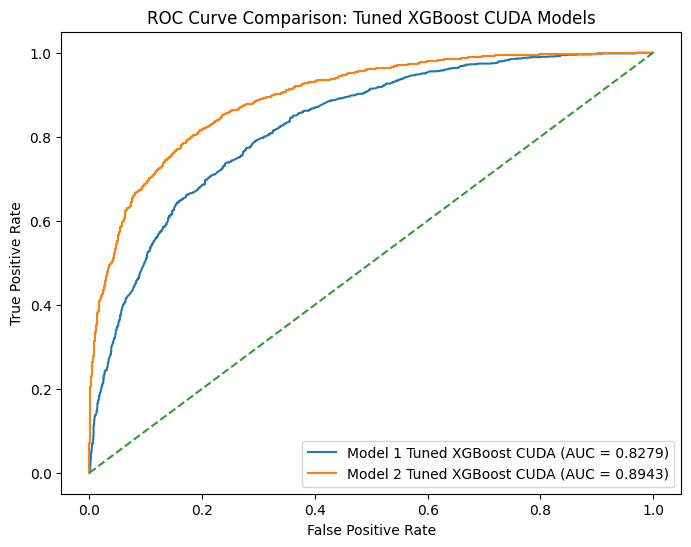

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob_model1 = model1_xgb_rs.predict_proba(X_test_1)[:, 1]
y_prob_model2 = model2_xgb_rs.predict_proba(X_test_2)[:, 1]

auc_model1 = roc_auc_score(y_test_1, y_prob_model1)
auc_model2 = roc_auc_score(y_test_2, y_prob_model2)

print("Validation AUC-ROC")
print("Model 1 (Non-text only, tuned XGBoost CUDA):", round(auc_model1, 4))
print("Model 2 (Non-text + LSI text, tuned XGBoost CUDA):", round(auc_model2, 4))

if auc_model2 > auc_model1:
    print("Model 2 performs better based on AUC-ROC.")
elif auc_model1 > auc_model2:
    print("Model 1 performs better based on AUC-ROC.")
else:
    print("Both models have the same AUC-ROC.")

fpr1, tpr1, _ = roc_curve(y_test_1, y_prob_model1)
fpr2, tpr2, _ = roc_curve(y_test_2, y_prob_model2)

plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f"Model 1 Tuned XGBoost CUDA (AUC = {auc_model1:.4f})")
plt.plot(fpr2, tpr2, label=f"Model 2 Tuned XGBoost CUDA (AUC = {auc_model2:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Tuned XGBoost CUDA Models")
plt.legend(loc="lower right")
plt.show()

CUDA WOOOOOOOOOOOOOOOOOOOOOOOOOOOOO, took 20 god damn seconds